Here, we apply normalization/dimensionality reduction/batch correections to the counts matrix:

In [1]:
import time
import os

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.decomposition import PCA

import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

## Covariate Associations

Use the first n_pcs to understand which covariates are most associated with PC variance:

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

### Cell Cycle Deep Dive

Looks like drug is not a particularly strong source of variance. We will correct for these various other variance sources to capture those that we care about. First, let's look at the relationship between "phase", "G2M_score", and "S_score" since these are all indicators of cell cycle. If they're all closely associated, we probably only need to correct for one.

Let's use a PC component that captures all 3 metrics:

In [5]:
phase_dummies = pd.get_dummies(adata.obs['phase'], prefix='phase').astype(int)
X = pd.concat([adata.obs[['S_score', 'G2M_score']], phase_dummies], axis=1)

pca_mod = PCA(n_components=1, random_state = seed)
pca_mod.fit(X) # fit to all 3 metrics

var_explained_pc1 = pca_mod.explained_variance_ratio_[0]
print(f"Variance explained by PC1 of aggregated cell cycle metrics: {var_explained_pc1:.3%}")

cell_cycle_pc1 = pca_mod.transform(X)
adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]

Variance explained by PC1 of aggregated cell cycle metrics: 70.677%


Looks like the PC well accounts for all 3 cell cycle metrics, atleast linearly. So, we will use this as our cell cycle covariate.

## Covariate correction

In [6]:
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata.obs.loc[X.index, 'cell_cycle_PC1'] = cell_cycle_pc1[:, 0]


In [7]:
plate_dummies = pd.get_dummies(adata.obs['plate'], prefix='plate').astype(float)
for col in plate_dummies.columns:
    adata.obs[col] = plate_dummies[col]
    
batch_keys = ['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist()

Linear:

In [ ]:
adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(
    adata_hvg, 
    keys=['pcnt_mito', 'cell_cycle_PC1'] + plate_dummies.columns.tolist(),
    n_jobs = n_cores)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/

In [11]:
adata_hvg.write_h5ad(os.path.join(data_path, 'interim', 'temp_regressed_counts.h5ad'))

In [17]:
adata_hvg = adata_hvr

In [18]:
%%time
sc.tl.pca(
    data = adata_hvg, 
    zero_center = True, # use cov matrix
    mask_var = 'highly_variable', # use hvgs -- all true in this case, already filtered
    random_state = seed)

CPU times: user 27min 52s, sys: 2.3 s, total: 27min 55s
Wall time: 2min 24s


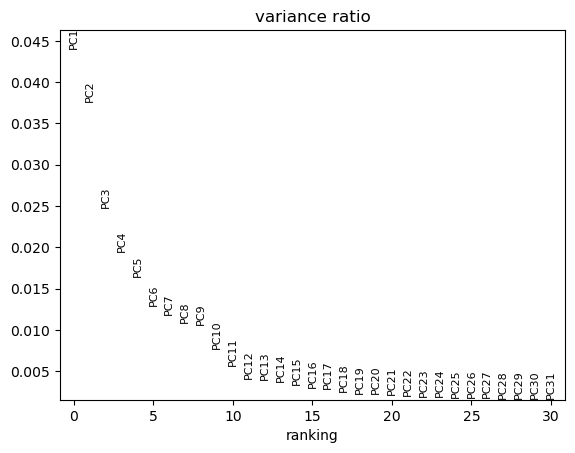

The elbow was automatically identified at PC 12


In [19]:
n_pcs = pp._compute_elbow(adata_hvg, curve='convex', direction='decreasing')
adata_hvg.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata_hvg)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [20]:
n_cores = 30

In [21]:
r2_df_linear = pp.pc_association(
    adata = adata,
    covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
    model_type = 'linear', 
    n_cores = n_cores, 
    seed = seed
)

r2_df_nl = pp.pc_association(
    adata = adata,
    covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
    model_type = 'nonlinear', 
    n_cores = n_cores, 
    seed = seed
)

r2_df = pd.concat([r2_df_linear, r2_df_nl])
r2_df.to_csv(os.path.join(data_path, 'processed', author + '_geneexpr_linearcorrected_pc_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', 
                                 author + '_geneexpr_linearcorrected_pc_associations.csv'), 
                   index_col = 0)

cell_line


100%|███████████████████████████████████████████| 13/13 [00:03<00:00,  4.19it/s]


drug


100%|███████████████████████████████████████████| 13/13 [00:12<00:00,  1.07it/s]


plate


...

100%|███████████████████████████████████████████| 13/13 [03:39<00:00, 16.88s/it]


G2M_score


100%|███████████████████████████████████████████| 13/13 [04:14<00:00, 19.59s/it]


pcnt_mito


100%|███████████████████████████████████████████| 13/13 [12:33<00:00, 57.98s/it]
